In [46]:
import pandas as pd
import numpy as np
import pymc as pm
import scipy.stats as stats
import arviz as az

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, minmax_scale

from gurobipy import *
import pytensor.tensor as pt

## Get player details


In [2]:
players_preds = pd.read_csv('./../FPL predictors/with new features/models/preds/players_preds_36.csv', index_col=0)
fpl_teams_ids = pd.read_csv('../FPL predictors/with new features/data/fpl_names_24_25.csv')

# Add fpl_id to player_preds
players_preds = players_preds.merge(fpl_teams_ids, left_on='fpl_name', right_on='FPL_Name', how='left')
players_preds.dropna(subset=['FPL_ID'], inplace=True)

players_preds = players_preds.drop(['event', 'understat_name', 'fpl_name', 'FPL_ID','FPL_Name', 'team', 'xG_preds', 'xA_preds', 'cs_preds', 'y_preds', 'saves_preds', 'xgc_preds', 'h_team', 'a_team','was_home'], axis=1)
player_cols = players_preds.columns.tolist()


In [3]:
gw=35
data_22_23 = pd.read_csv('../FPL predictors/with new features/data/joint/22-23/merged_player_data.csv',).dropna()
data_23_24 = pd.read_csv('../FPL predictors/with new features/data/joint/23-24/merged_player_data.csv').dropna()
data_24_25 = pd.read_csv('../FPL predictors/with new features/data/joint/24-25/merged_player_data.csv')

data_tar = data_24_25[data_24_25['event']==gw]
data_24_25_ = data_24_25[data_24_25['event'] < gw]
data_24_25_test = data_24_25[data_24_25['event'] > gw]

data = pd.concat([data_22_23, data_23_24, data_24_25_])

data_cols = player_cols.copy()
data_cols.pop(data_cols.index('xP_preds'))
data_cols.pop(data_cols.index('player_team'))


data_ = data[data_cols]
gk_data = data[data['position'] == 'GK'][data_cols]
def_data = data[data['position'] == 'DEF'][data_cols]
mid_data = data[data['position'] == 'MID'][data_cols]
fwd_data = data[data['position'] == 'FWD'][data_cols]

gk_data = gk_data.select_dtypes(include=[np.number])
gk_data = gk_data.dropna()
gk_data = pd.DataFrame(minmax_scale(gk_data), columns=gk_data.columns, index=gk_data.index)

def_data = def_data.select_dtypes(include=[np.number])
def_data = def_data.dropna()
def_data = pd.DataFrame(minmax_scale(def_data), columns=def_data.columns, index=def_data.index)

mid_data = mid_data.select_dtypes(include=[np.number])
mid_data = mid_data.dropna()
mid_data = pd.DataFrame(minmax_scale(mid_data), columns=mid_data.columns, index=mid_data.index)

fwd_data = fwd_data.select_dtypes(include=[np.number])
fwd_data = fwd_data.dropna()
fwd_data = pd.DataFrame(minmax_scale(fwd_data), columns=fwd_data.columns, index=fwd_data.index)

In [4]:

X_def = def_data  # shape: (n_defenders, n_features)

# 1. Standardize (PCA works best on standardized data)
scaler_gk = StandardScaler(with_mean=True, with_std=True)
scaler_def = StandardScaler(with_mean=True, with_std=True)
scaler_mid = StandardScaler(with_mean=True, with_std=True)
scaler_fwd = StandardScaler(with_mean=True, with_std=True)

X_gk = scaler_gk.fit_transform(gk_data)
X_def = scaler_def.fit_transform(def_data)
X_mid = scaler_mid.fit_transform(mid_data)
X_fwd = scaler_fwd.fit_transform(fwd_data)


# 2. Choose # of components or variance threshold
pca_gk = PCA(n_components=0.95)  # 0.95 = keep enough PCs to explain 95% of variance
pca_def = PCA(n_components=0.95)
pca_mid = PCA(n_components=0.95)
pca_fwd = PCA(n_components=0.95)

# 3. Fit PCA and transform
X_gk_pca = pd.DataFrame(pca_gk.fit_transform(X_gk))
X_def_pca = pd.DataFrame(pca_def.fit_transform(X_def))
X_mid_pca = pd.DataFrame(pca_mid.fit_transform(X_mid))
X_fwd_pca = pd.DataFrame(pca_fwd.fit_transform(X_fwd))

print("Original shape:", X_gk.shape, X_def.shape, X_mid.shape, X_fwd.shape)
print("Reduced shape:", X_gk_pca.shape, X_def_pca.shape, X_mid_pca.shape, X_fwd_pca.shape)

# # 4. Check variance explained
# print("Explained variance ratio per PC:", pca_gk.explained_variance_ratio_)
# print("Cumulative explained variance:", np.cumsum(pca_gk.explained_variance_ratio_))


Original shape: (501, 236) (2387, 236) (3823, 236) (863, 236)
Reduced shape: (501, 65) (2387, 69) (3823, 69) (863, 65)


In [5]:
data_ = players_preds[data_cols]
gk_data_tar = players_preds[players_preds['position'] == 'GK'][gk_data.columns]
def_data_tar = players_preds[players_preds['position'] == 'DEF'][def_data.columns]
mid_data_tar = players_preds[players_preds['position'] == 'MID'][mid_data.columns]
fwd_data_tar = players_preds[players_preds['position'] == 'FWD'][fwd_data.columns]


gk_data_tar = gk_data_tar.select_dtypes(include=[np.number])
gk_data_tar = pd.DataFrame(minmax_scale(gk_data_tar), columns=gk_data_tar.columns, index=gk_data_tar.index)

def_data_tar = def_data_tar.select_dtypes(include=[np.number])
# Data
def_data_tar = pd.DataFrame(minmax_scale(def_data_tar), columns=def_data_tar.columns, index=def_data_tar.index)

mid_data_tar = mid_data_tar.select_dtypes(include=[np.number])
mid_data_tar = pd.DataFrame(minmax_scale(mid_data_tar), columns=mid_data_tar.columns, index=mid_data_tar.index)

fwd_data_tar = fwd_data_tar.select_dtypes(include=[np.number])
fwd_data_tar = pd.DataFrame(minmax_scale(fwd_data_tar), columns=fwd_data_tar.columns, index=fwd_data_tar.index)

# Make sure there are no nan or inf
def clean_array(arr):
    arr = np.nan_to_num(arr, nan=0.0, posinf=1e6, neginf=-1e6)
    return arr

gk_data_tar  = clean_array(gk_data_tar)
def_data_tar = clean_array(def_data_tar)
mid_data_tar = clean_array(mid_data_tar)
fwd_data_tar = clean_array(fwd_data_tar)


In [6]:
X_gk_tar = scaler_gk.transform(gk_data_tar)
X_def_tar = scaler_def.transform(def_data_tar)
X_mid_tar = scaler_mid.transform(mid_data_tar)
X_fwd_tar = scaler_fwd.transform(fwd_data_tar)


# 3. Fit PCA and transform
X_gk_pca_tar = pd.DataFrame(pca_gk.transform(X_gk_tar))
X_def_pca_tar = pd.DataFrame(pca_def.transform(X_def_tar))
X_mid_pca_tar = pd.DataFrame(pca_mid.transform(X_mid_tar))
X_fwd_pca_tar = pd.DataFrame(pca_fwd.transform(X_fwd_tar))

print("Original shape:", X_gk_tar.shape, X_def_tar.shape, X_mid_tar.shape, X_fwd_tar.shape)
print("Reduced shape:", X_gk_pca_tar.shape, X_def_pca_tar.shape, X_mid_pca_tar.shape, X_fwd_pca_tar.shape)

# # 4. Check variance explained
# print("Explained variance ratio per PC:", pca_gk.explained_variance_ratio_)
# print("Cumulative explained variance:", np.cumsum(pca_gk.explained_variance_ratio_))

Original shape: (17, 236) (93, 236) (136, 236) (28, 236)
Reduced shape: (17, 65) (93, 69) (136, 69) (28, 65)


c:\Users\Ilyas\anaconda3\envs\Pycaret\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Ilyas\anaconda3\envs\Pycaret\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Ilyas\anaconda3\envs\Pycaret\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\Ilyas\anaconda3\envs\Pycaret\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## Wo Component


In [164]:
def get_beta(data):
    # Ensure data is numeric
    data = data.select_dtypes(include=[np.number])  # Drop non-numeric columns

    # Shape parameters
    np.random.seed(42)
    num_players, num_features = data.shape

    print(f"Number of Players: {num_players}, Features: {num_features}")

    # Convert to NumPy with float type
    X = data.to_numpy(dtype=np.float64)
    X = X.reshape((num_players, num_features))
    print(X.shape)

    # Observed probability distribution (Ensure valid probabilities)
    p = np.abs(np.random.randn(num_players, ))
    p /= p.sum( keepdims=True)  # Normalize to sum to 1
    print("p shape:", p.shape)

    with pm.Model() as model:
        # Prior: Uniform distribution for β
        beta = pm.Uniform("beta", lower=-1, upper=1, shape=(num_features,))
        print("Beta shape:", beta.shape)

        # Compute α = exp(X β) and ensure correct shape
        epsilon = 1e-3
        alpha = pm.math.exp(pm.math.dot(X, beta)) + epsilon
        print("Alpha shape:", alpha.shape)

        # Dirichlet likelihood (Ensure shape matches p)
        p = pm.Dirichlet("p", a=alpha, observed=p)
        # Debugging step to check the model
        model.debug(verbose=True)
        # MCMC Sampling
        trace = pm.sample(2000, return_inferencedata=True, target_accept=0.9)

    # Get estimated β values
    beta_estimated = trace.posterior["beta"].mean(dim=["chain", "draw"])
    print("Estimated β values:", beta_estimated.values)
    return beta_estimated

### Get betas


In [165]:
def simulate_observed_probs(X: pd.DataFrame):
    X = X.fillna(0)
    np.random.seed(42)
    num_features = X.shape[1]
    true_beta = np.random.uniform(-0.5, 0.5, size=(num_features,))
    logits = X @ true_beta
    probs = np.exp(logits)
    probs /= probs.sum()
    return probs

simulate_observed_probs(gk_data)

23       0.001270
24       0.000815
25       0.001514
26       0.001125
27       0.004494
           ...   
11071    0.000870
11072    0.000464
11073    0.001270
11074    0.001883
11075    0.001015
Length: 501, dtype: float64

In [166]:
def dirichlet_regression_beta_auto(data: pd.DataFrame):
    """
    Perform Bayesian Dirichlet Regression.
    If no observed_probs are given, simulate them based on features.
    """
    if not isinstance(data, pd.DataFrame):
        raise ValueError("Data must be a pandas DataFrame.")

    if data.isnull().any().any():
        raise ValueError("Data contains NaN values. Please clean it first.")

    num_players, num_features = data.shape
    print(f"Number of Players: {num_players}, Number of Features: {num_features}")

    X = data.to_numpy(dtype=np.float64)
    # X = X.fillna(0)

    # --- Simulate observed probabilities ---
    observed_probs = simulate_observed_probs(data)

    with pm.Model() as model:
        # Wide normal prior
        beta = pm.Normal("beta", mu=0, sigma=10, shape=(num_features,))

        eta = pm.math.dot(X, beta)
        alpha = pm.math.exp(eta)

        pm.Dirichlet("obs", a=alpha, observed=observed_probs)

        trace = pm.sample(
            draws=1000,
            tune=50,
            target_accept=0.95,
            chains=2,
            cores=2,
            return_inferencedata=True,
            progressbar=True,
            # nuts_sampler="numpyro"
        )

    beta_estimated = trace.posterior["beta"].mean(dim=["chain", "draw"]).values

    print("Estimated β values:\n", beta_estimated)
    return beta_estimated

In [167]:
# Suppose your player data
X_data_gk = X_gk_pca.copy()
# X_data_gk = X_data_gk.fillna(0)
# Now fit!
beta_gk = dirichlet_regression_beta_auto(X_data_gk)
# eta_gk = get_beta(gk_data)

Number of Players: 501, Number of Features: 65


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [beta]


Output()

Sampling 2 chains for 50 tune and 1_000 draw iterations (100 + 2_000 draws total) took 44 seconds.
There were 838 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Estimated β values:
 [ 0.03257873  0.21703899 -0.05731617 -0.14697469 -0.25155589 -0.34760067
  0.06618315  0.43758989 -0.11519272  0.10965568 -0.37425565 -0.13996754
  0.01948526 -0.10293993  0.48770835  0.44128104  0.18291237  0.27102492
  0.15932239  0.35922412  0.09515201 -0.47030975 -0.53582649  0.16467204
  0.408959    0.03124879 -0.38375632 -0.20614641  0.22085138 -0.2521389
  0.5926203  -0.50858263  0.26247805 -0.05016929 -0.33997879  0.41079132
 -0.34070096 -0.32655346  0.14745566  0.3137136   0.40731733  0.36351758
 -0.26109035 -0.11644832 -0.22035836  0.32583685 -0.37164678 -0.49577121
  0.13845979  0.16323692 -0.08204703 -0.4207873   0.14505821  0.28218168
  0.1066638  -0.41446998 -0.03713278 -0.2982112  -0.20987363  0.37246646
  0.32514385  0.38849503  0.37887777 -0.07236546 -0.17766151]


In [168]:
# Suppose your player data
X_data_def = X_def_pca.copy()

# Now fit!
beta_def = dirichlet_regression_beta_auto(X_data_def)

Number of Players: 2387, Number of Features: 69


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [beta]


Output()

Sampling 2 chains for 50 tune and 1_000 draw iterations (100 + 2_000 draws total) took 2408 seconds.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Estimated β values:
 [ 0.03037517 -0.02358485  0.19305244 -0.28464877  0.09487231 -0.00173055
 -0.60994936  0.422781   -0.30848393  0.16969887 -0.38227898 -0.15243347
  0.60538909 -0.13682198 -0.41415226 -0.45409538 -0.34400363 -0.10956767
  0.10321255 -0.1038173  -0.21190584 -0.05464924  0.0333638   0.05454436
 -0.07915266 -0.10874993 -0.54454161 -0.13361898 -0.14489582 -0.03434499
 -0.382099    0.25561513  0.076481    0.19812318  0.60216119 -0.33454023
  0.31041195 -0.27607096 -0.11298592  0.0907659  -0.56272496 -0.3442349
  0.16030322 -0.02802844 -0.27966957  0.51997122  0.17222194 -0.22692129
 -0.17533511 -0.48548623  0.08150387 -0.00400131  0.41781849  0.08144984
  0.10870152  0.4082659  -0.17735776 -0.12951253  0.06784466  0.27514707
  0.25453241 -0.35310955 -0.35878502 -0.40516466 -0.02953054  0.51171241
 -0.00539767  0.02093096  0.1793763 ]


In [169]:
# Suppose your player data
X_data_mid = X_mid_pca.copy()

# Now fit!
beta_mid = dirichlet_regression_beta_auto(X_data_mid)

Number of Players: 3823, Number of Features: 69


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [beta]


Output()

Sampling 2 chains for 50 tune and 1_000 draw iterations (100 + 2_000 draws total) took 82 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Estimated β values:
 [ 0.03121174  0.16246742  0.48673851 -0.49106893  0.62309354 -0.20580563
  0.10622627  0.49983301 -0.3820418   0.28915862 -0.28511284 -0.67272525
  0.19043792 -0.28778252  0.50870447  0.04496095 -0.63616082 -0.07321143
 -0.02381804  0.12460616  0.18872528  0.60869419 -0.40853982 -0.06286243
  0.30569107  0.04968372 -0.27807234  0.79721442 -0.22884129 -0.33405243
 -0.2975201   0.68140407 -0.29283556 -0.85784895 -0.0699091   0.16856186
 -0.19908235 -0.14740595 -0.27486105 -0.25209246  0.05877918 -0.21484551
  0.71382342 -0.36610447  0.738486    0.57081802 -0.49943227  0.27946376
  0.54704321  0.0224208  -0.63561791 -0.14797627 -0.01636789  0.35577442
  0.5443706   0.39951615  0.495928   -0.68710832  0.31467964 -0.54483246
 -0.51322459 -0.12657836  0.47835961  0.4720997  -0.13627252 -0.03794842
 -0.14165751  0.36998094  0.01648897]


In [170]:
# Suppose your player data
X_data_fwd = X_fwd_pca.copy()
X_data_fwd = X_data_fwd.fillna(0)

# Now fit!
beta_fwd = dirichlet_regression_beta_auto(X_data_fwd)


Number of Players: 863, Number of Features: 65


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [beta]


Output()

Sampling 2 chains for 50 tune and 1_000 draw iterations (100 + 2_000 draws total) took 591 seconds.
Chain 1 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Estimated β values:
 [-0.08128872  0.14269223 -0.08280228  0.09626273  0.14773541 -0.21764601
 -0.11262666 -0.13757394  0.22865535 -0.12906601 -0.12334197 -0.40124217
 -0.07352353 -0.08207209 -0.37632436 -0.34617953 -0.04602838  0.13076712
 -0.10583299  0.04218604  0.21005063 -0.42102073  0.37306808  0.30929296
  0.26261499  0.05532308  0.29784499  0.22654179  0.32536979  0.05186617
 -0.25037629 -0.59635163 -0.08730469  0.11214957  0.50450586 -0.48253622
  0.12516683 -0.20862815 -0.61256888 -0.11795997  0.27565429 -0.46400897
  0.06733244  0.18257097 -0.22644252  0.16148277 -0.31367024  0.38823628
  0.43861623 -0.15784842  0.15402564  0.38018501 -0.63977412  0.56361627
 -0.52775002 -0.19678205 -0.52195559  0.45411242 -0.29356528  0.36226986
  0.01062004  0.52969737  0.75456753  0.36924318  0.51397751]


In [172]:
 # Convert to pandas DataFrame
pd.DataFrame({
    "gk": beta_gk
}).to_csv('./gk_beta.csv', index=False)

pd.DataFrame({
    "def": beta_def
}).to_csv('./def_beta.csv', index=False)

pd.DataFrame({
    "mid": beta_mid
}).to_csv('./mid_beta.csv', index=False)

pd.DataFrame({
    "fwd": beta_fwd
}).to_csv('./fwd_beta.csv', index=False)

### Use the betas


In [7]:
beta_gk_ = pd.read_csv('./gk_beta.csv').values.squeeze()
beta_def_ = pd.read_csv('./def_beta.csv').values.squeeze()
beta_mid_ = pd.read_csv('./mid_beta.csv').values.squeeze()
beta_fwd_ = pd.read_csv('./fwd_beta.csv').values.squeeze()

alpha_gk_pred = np.exp(np.dot(X_gk_pca_tar, beta_gk_.T))
alpha_def_pred = np.exp(np.dot(X_def_pca_tar, beta_def_.T))
alpha_mid_pred = np.exp(np.dot(X_mid_pca_tar, beta_mid_.T))
alpha_fwd_pred = np.exp(np.dot(X_fwd_pca_tar, beta_fwd_.T))

In [8]:
dir_gk = np.random.dirichlet(alpha_gk_pred).tolist()
dir_def = np.random.dirichlet(alpha_def_pred).tolist()
dir_mid = np.random.dirichlet(alpha_mid_pred).tolist()
dir_fwd = np.random.dirichlet(alpha_fwd_pred).tolist()

In [9]:
f = len(beta_gk_)  # Number of group

# Step 2: Define and sample from Dirichlet distribution
with pm.Model() as model:
    p_gk = pm.Dirichlet("p_gk", a=alpha_gk_pred)  # Ensure correct shape
    p_def = pm.Dirichlet("p_def", a=alpha_def_pred)  # Ensure correct shape
    p_mid = pm.Dirichlet("p_mid", a=alpha_mid_pred)  # Ensure correct shape
    p_fwd = pm.Dirichlet("p_fwd", a=alpha_fwd_pred)  # Ensure correct shape

    trace = pm.sample_prior_predictive(samples=1)

Sampling: [p_def, p_fwd, p_gk, p_mid]


In [10]:
# Extract samples correctly
sampled_p_gk = trace.prior["p_gk"].values.squeeze()  # Ensure shape is (f, num_features)
sampled_p_def = trace.prior["p_def"].values.squeeze()  # Ensure shape is (f, num_features)
sampled_p_mid = trace.prior["p_mid"].values.squeeze()  # Ensure shape is (f, num_features)
sampled_p_fwd = trace.prior["p_fwd"].values.squeeze()  # Ensure shape is (f, num_features)"


In [11]:
W = set()  # Placeholder for valid portfolios
Wo = []  # List to store accepted portfolios

In [12]:
# # Ensure sampled probabilities are valid
# sampled_p_gk = np.nan_to_num(sampled_p_gk, nan=1.0 / len(sampled_p_gk))
# sampled_p_def = np.nan_to_num(sampled_p_def, nan=1.0 / len(sampled_p_def))
# sampled_p_mid = np.nan_to_num(sampled_p_mid, nan=1.0 / len(sampled_p_mid))
# sampled_p_fwd = np.nan_to_num(sampled_p_fwd, nan=1.0 / len(sampled_p_fwd))

# # Normalize probabilities to ensure they sum to 1
# sampled_p_gk /= sampled_p_gk.sum()
# sampled_p_def /= sampled_p_def.sum()
# sampled_p_mid /= sampled_p_mid.sum()
# sampled_p_fwd /= sampled_p_fwd.sum()

# # Generate random samples
# gk = np.random.multinomial(1, sampled_p_gk)
# def_ = np.random.multinomial(3, sampled_p_def)
# mid = np.random.multinomial(4, sampled_p_mid)
# fwd = np.random.multinomial(4, sampled_p_fwd)

# # Extract indices of selected players
# gk_idx = [i for i, x in enumerate(gk) if x == 1]
# def_idx = [i for i, x in enumerate(def_) if x == 1]
# mid_idx = [i for i, x in enumerate(mid) if x == 1]
# fwd_idx = [i for i, x in enumerate(fwd) if x == 1]

# gk_idx, def_idx, mid_idx, fwd_idx

In [13]:
# # Manually compute alpha values and check ranges
# epsilon = 1e-3
# alpha_g = np.exp(np.dot(X_gk_pca_tar, beta_gk_.T)) #+ epsilon
# alpha_d = np.exp(np.dot(X_def_pca_tar, beta_def_.T)) #+ epsilon
# alpha_m = np.exp(np.dot(X_mid_pca_tar, beta_mid_.T)) #+ epsilon
# alpha_f = np.exp(np.dot(X_fwd_pca_tar, beta_fwd_.T)) #+ epsilon

# print("Alpha gk: min", alpha_g.min(), " max", alpha_g.max())
# print("Alpha def: min", alpha_d.min(), " max", alpha_d.max())
# print("Alpha mid: min", alpha_m.min(), " max", alpha_m.max())
# print("Alpha fwd: min", alpha_f.min(), " max", alpha_f.max())


In [14]:
# === Step 1: Define Constants ===
P = 100  # Total available players
C = 15  # Squad size
cin = 11  # Starting lineup size
budget = 100  # Maximum budget
Blb = 95  # Lower bound on spent budget
O = 1000  # Number of squad simulations

# Example positions: Assume these are valid players for selection
Pg, Pd, Pm, Pf = len(gk_data_tar), len(def_data_tar), len(mid_data_tar), len(fwd_data_tar)  # Players per position
positions = {"g": Pg, "d": Pd, "m": Pm, "f": Pf}

# === Step 2: Generate Dirichlet Parameters for Position Selection ===
epsilon = 1e-3  # Small constant to avoid numerical issues

def safe_alpha(X_pca, beta):
    raw_scores = pm.math.dot(X_pca, beta.T)
    raw_scores -= pm.math.max(raw_scores)
    alpha = pm.math.exp(raw_scores) + epsilon
    alpha = pm.math.clip(alpha, 1e-3, 1e3)
    return alpha

alpha_g = safe_alpha(X_gk_pca_tar, beta_gk_)
alpha_d = safe_alpha(X_def_pca_tar, beta_def_)
alpha_m = safe_alpha(X_mid_pca_tar, beta_mid_)
alpha_f = safe_alpha(X_fwd_pca_tar, beta_fwd_)

with pm.Model():
    pg = pm.Dirichlet("pg", a=alpha_g)  # Ensure correct shape
    pd_ = pm.Dirichlet("pd_", a=alpha_d)  # Ensure correct shape
    pmid = pm.Dirichlet("pm", a=alpha_m)  # Ensure correct shape
    pf = pm.Dirichlet("pf", a=alpha_f)  # Ensure correct shape

    trace = pm.sample(
            draws=1000,
            tune=500,
            target_accept=0.95,
            chains=4,
            cores=2,
            return_inferencedata=True,
            progressbar=True)

# Extract posterior means
pgk, pdef, pmid, pfwd = (
    trace.posterior["pg"].mean(dim=("chain", "draw")).values,
    trace.posterior["pd_"].mean(dim=("chain", "draw")).values,
    trace.posterior["pm"].mean(dim=("chain", "draw")).values,
    trace.posterior["pf"].mean(dim=("chain", "draw")).values,)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [pg, pd_, pm, pf]


Output()

Sampling 4 chains for 500 tune and 1_000 draw iterations (2_000 + 4_000 draws total) took 285 seconds.
There were 4000 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


c:\Users\Ilyas\anaconda3\envs\Pycaret\Lib\site-packages\arviz\stats\density_utils.py:699: RuntimeWarning: overflow encountered in divide
  f = grid_counts / bin_width / len(x)
c:\Users\Ilyas\anaconda3\envs\Pycaret\Lib\site-packages\arviz\plots\kdeplot.py:265: RuntimeWarning: invalid value encountered in divide
  density_q = density if cumulative else density.cumsum() / density.sum()
c:\Users\Ilyas\anaconda3\envs\Pycaret\Lib\site-packages\arviz\stats\density_utils.py:249: RuntimeWarning: divide by zero encountered in scalar power
  out = t - (2 * N * np.pi**0.5 * f) ** (-0.4)
c:\Users\Ilyas\anaconda3\envs\Pycaret\Lib\site-packages\arviz\stats\density_utils.py:699: RuntimeWarning: overflow encountered in divide
  f = grid_counts / bin_width / len(x)
c:\Users\Ilyas\anaconda3\envs\Pycaret\Lib\site-packages\arviz\stats\density_utils.py:720: RuntimeWarning: invalid value encountered in divide
  pdf /= bw * (2 * np.pi) ** 0.5


array([[<Axes: title={'center': 'pg'}>, <Axes: title={'center': 'pg'}>],
       [<Axes: title={'center': 'pd_'}>, <Axes: title={'center': 'pd_'}>],
       [<Axes: title={'center': 'pm'}>, <Axes: title={'center': 'pm'}>],
       [<Axes: title={'center': 'pf'}>, <Axes: title={'center': 'pf'}>]],
      dtype=object)

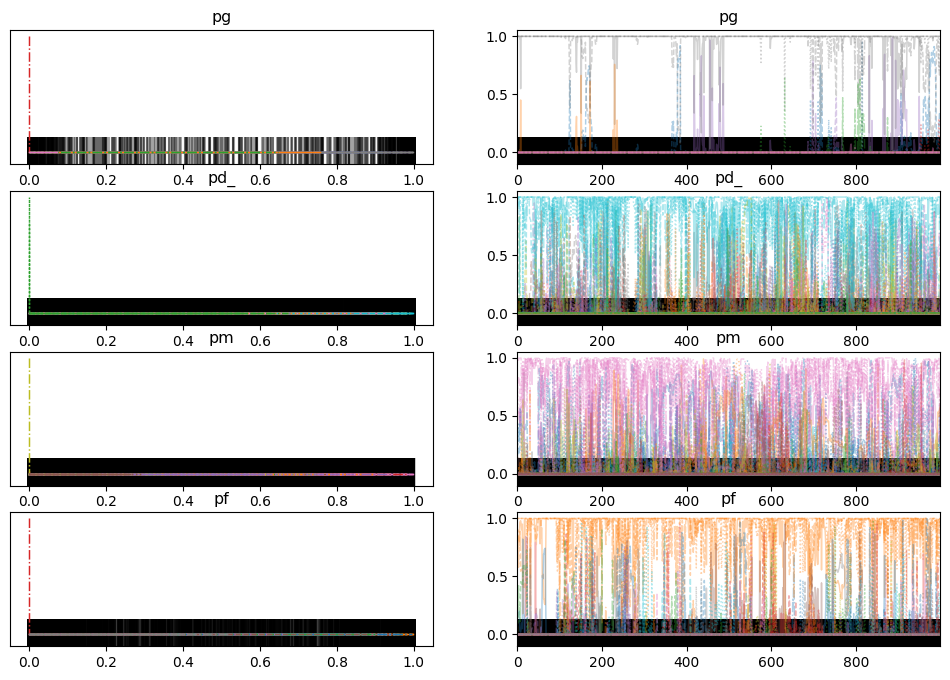

In [15]:

az.plot_trace(data=trace, var_names=["pg", "pd_", 'pm', 'pf'])

In [17]:
pg_ = pd.DataFrame({'gk': pgk})
pd_ = pd.DataFrame({'def': pdef})
pmid_ = pd.DataFrame({'mid': pmid})
pf_ = pd.DataFrame({'fwd': pfwd})

pg_.to_csv('./gk_beta_post.csv', index=False)
pd_.to_csv('./def_beta_post.csv', index=False)
pmid_.to_csv('./mid_beta_post.csv', index=False)
pf_.to_csv('./fwd_beta_post.csv', index=False)

### Generate Wo


In [18]:
fpl_teams_ids = pd.read_csv('../FPL predictors/with new features/data/fpl_names_24_25.csv')
fpl_teams_ids

,FPL_ID,FPL_Name
0,517,Aaron Cresswell
1,93,Aaron Hickey
2,14,Aaron Ramsdale
3,388,Aaron Wan-Bissaka
4,217,Abdoulaye Doucouré
...,...,...
704,676,Zach Marsh
705,26,Álex Moreno Lopera
706,151,Ângelo Gabriel Borges Damaceno
707,183,Đorđe Petrović


In [19]:
pg_curr = pd.read_csv('./gk_beta_post.csv').values.squeeze()
pd_curr = pd.read_csv('./def_beta_post.csv').values.squeeze()
pm_curr = pd.read_csv('./mid_beta_post.csv').values.squeeze()
pf_curr = pd.read_csv('./fwd_beta_post.csv').values.squeeze()

players_preds = pd.read_csv('./../FPL predictors/with new features/models/preds/players_preds_36.csv', index_col=0)
fpl_teams_ids = pd.read_csv('../FPL predictors/with new features/data/fpl_names_24_25.csv')

# Add fpl_id to player_preds
players_preds = players_preds.merge(fpl_teams_ids, left_on='fpl_name', right_on='FPL_Name', how='left')
players_preds.dropna(subset=['FPL_ID'], inplace=True)

g_prices = players_preds[players_preds['position'] == 'GK'][['value']] #*10
d_prices = players_preds[players_preds['position'] == 'DEF'][['value']] #*10
m_prices = players_preds[players_preds['position'] == 'MID'][['value']] #*10
f_prices = players_preds[players_preds['position'] == 'FWD'][['value']] #*10

g_xPts = players_preds[players_preds['position'] == 'GK']['xP_preds'].tolist()
d_xPts = players_preds[players_preds['position'] == 'DEF']['xP_preds'].tolist()
m_xPts = players_preds[players_preds['position'] == 'MID']['xP_preds'].tolist()
f_xPts = players_preds[players_preds['position'] == 'FWD']['xP_preds'].tolist()

g_teams = players_preds[players_preds['position'] == 'GK']['player_team'].tolist()
d_teams = players_preds[players_preds['position'] == 'DEF']['player_team'].tolist()
m_teams = players_preds[players_preds['position'] == 'MID']['player_team'].tolist()
f_teams = players_preds[players_preds['position'] == 'FWD']['player_team'].tolist()

g_ids = players_preds[players_preds['position'] == "GK"]['FPL_ID'].tolist()
d_ids = players_preds[players_preds['position'] == "DEF"]['FPL_ID'].tolist()
m_ids = players_preds[players_preds['position'] == "MID"]['FPL_ID'].tolist()
f_ids = players_preds[players_preds['position'] == "FWD"]['FPL_ID'].tolist()


all_xPts = g_xPts + d_xPts + m_xPts + f_xPts

In [20]:
from collections import Counter

# === Step 1: Define Constants ===
P = 100  # Total available players
C = 11  # Squad size
cin = 11  # Starting lineup size
budget = 100  # Maximum budget
Blb = 95  # Lower bound on spent budget"

O = 50  # Number of squad simulations

O = 5000  # Number of squad simulations"

q = 0.25  # Assume 30% stacking probability

gk_sizes = [1]
def_sizes = [3,4,5]
mid_sizes = [2,3,4,5]
fwd_sizes = [1,2,3]
Wo = set()
# === Step 3: Generate Possible Team Selections (Algorithm 1) ===
def generate_squad(pg, pdef, pmid, pf, q, budget):

    """Generate a valid team selection for an opponent."""
    stack = np.random.binomial(1, q)  # Stacking decision


    # print('===============================> Adding Goalkeeper')

    while True:
        selected_g = np.random.multinomial(1, pg)
        if set(selected_g) <= {0, 1}:  # Ensure only 1s and 0s exist
            break
    g_cost = np.dot(selected_g, g_prices)[0]
    g_team_idx = [idx for idx, _ in enumerate(selected_g) if selected_g[idx] == 1]
    selected_team_g = [g_teams[i] for i in g_team_idx] # Get the selected teams
    squad_g = [g_ids[i] for i in g_team_idx]

    for i in def_sizes:
        # print('===============================> Adding Defender', i)
        while True: # substitute for a do_while loop
            while True:# Ensure only 1s and 0s exist
                selected_d = np.random.multinomial(i, pdef)
                if set(selected_d) <= {0, 1}:  # Ensure only 1s and 0s exist
                    break
            d_cost = np.dot(selected_d, d_prices)[0]
            d_team_idx = [idx for idx, _ in enumerate(selected_d) if selected_d[idx] == 1]
            selected_team_g_d = selected_team_g + [d_teams[i] for i in d_team_idx] # Get the selected teams
            squad_g_d = squad_g + [d_ids[i] for i in d_team_idx]

            if ((not any(team >=3 for team in Counter(selected_team_g_d).values())) and g_cost + d_cost < Blb):
                # Check if no more than 3 players from the same team are selected
                # If the cost is below the lower bound, break and continue to the next iteration
                break

        for j in mid_sizes:
            # print('===============================> Adding Midfielder ',i,  j)
            while True: # substitute for a do_while loop
                while True:
                    selected_m = np.random.multinomial(j, pmid)
                    if set(selected_m) <= {0, 1}:  # Ensure only 1s anm0s exist
                        break
                m_cost = np.dot(selected_m, m_prices)[0]
                m_team_idx = [idx for idx, _ in enumerate(selected_m) if selected_m[idx] == 1]
                selected_team_g_d_m = selected_team_g_d + [m_teams[i] for i in m_team_idx] # Get the selected teams
                squad_g_d_m = squad_g_d + [m_ids[i] for i in m_team_idx]

                if  ((not any(team >=3 for team in Counter(selected_team_g_d_m).values())) and g_cost + d_cost + m_cost < Blb):
                    # Check if no more than 3 players from the same team are selected
                    # If the cost is below the lower bound, break and continue to the next iteration
                    break

            for k in fwd_sizes:
                # print('===============================> Adding Forward ',i,  j, k)
                if(i+j+k < 10 or i+j+k > 10):
                    continue

                while True:
                    while True:
                        selected_f = np.random.multinomial(k, pf)
                        if set(selected_f) <= {0, 1}:  # Ensure only 1s anm0s exist
                            break
                    f_cost = np.dot(selected_f, f_prices)[0]

                    f_team_idx = [idx for idx, _ in enumerate(selected_f) if selected_f[idx] == 1]
                    selected_team_g_d_m_f = selected_team_g_d_m + [f_teams[i] for i in f_team_idx] # Get the selected teams
                    squad_g_d_m_f = squad_g_d_m + [f_ids[i] for i in f_team_idx]

                    squad_cost = g_cost + d_cost + m_cost + f_cost
                    print(squad_cost)
                    if  ((not any(team >=3 for team in Counter(selected_team_g_d_m_f).values())) and  squad_cost < Blb): # 70 <

                    #if((not any(team >=3 for team in Counter(selected_team_g_d_m_f).values())) and g_cost + d_cost + m_cost + f_cost < Blb):

                        # Check if no more than 3 players from the same team are selected
                        # If the cost is below the lower bound, break and continue to the next iteration
                        Wo.add(tuple(squad_g_d_m_f))
                        break

squad = generate_squad(pg_curr, pd_curr, pm_curr, pf_curr, q, budget)
len(Wo)
# Generate O possible squads
while len(Wo)  < O:
    generate_squad(pg_curr, pd_curr, pm_curr, pf_curr, q, budget)
    print(f'-------------------------------> {len(Wo)} ===> {(len(Wo)/O)*100}%')
# Print example squad
print("Example Generated Squad:", len(Wo))

74.7
80.60000000000001
74.60000000000001
65.4
69.5
70.4
77.1
71.0
76.8
72.9
72.0
80.7
75.2
71.7
67.9
68.4
69.8
56.8
69.7
-------------------------------> 16 ===> 0.32%
70.2
68.0
75.2
68.7
79.8
70.89999999999999
70.2
73.9
69.89999999999999
64.9
-------------------------------> 24 ===> 0.48%
74.3
71.3
79.6
81.5
72.5
69.89999999999999
72.5
71.3
81.39999999999999
81.39999999999999
71.19999999999999
73.1
80.19999999999999
78.6
78.3
71.3
72.5
62.49999999999999
70.9
71.2
71.10000000000001
-------------------------------> 32 ===> 0.64%
72.6
80.4
78.0
83.9
76.0
68.9
68.4
72.4
71.20000000000002
-------------------------------> 40 ===> 0.8%
77.7
69.1
73.1
70.2
67.6
70.5
67.6
68.2
77.1
68.80000000000001
70.80000000000001
68.2
77.7
70.5
68.2
80.7
77.7
68.30000000000001
72.4
66.8
68.80000000000001
78.9
79.0
79.4
73.6
67.1
67.7
77.7
69.1
67.4
69.7
77.6
79.0
72.7
70.6
69.2
77.1
70.1
70.5
77.4
66.8
68.80000000000001
68.80000000000001
71.80000000000001
79.5
71.80000000000001
67.4
76.30000000000001
71.80

## Covariance Matrix


In [21]:
xp_lookup = dict(zip(players_preds['FPL_ID'], players_preds['xP_preds']))
G_ = [ np.sum([xp_lookup.get(id_, 0) for id_ in wo_]) for wo_ in Wo]


In [22]:
Wo_ = []
player_ids  = players_preds['FPL_ID'].tolist()
print(player_ids)
for i in Wo:
    # Create a tuple of 0s and 1s for each player
    squad = tuple([1 if id_ in i else 0 for id_ in player_ids])
    Wo_.append(squad)


[517.0, 14.0, 388.0, 217.0, 81.0, 147.0, 239.0, 372.0, 247.0, 77.0, 401.0, 329.0, 310.0, 513.0, 233.0, 240.0, 335.0, 432.0, 398.0, 78.0, 365.0, 489.0, 238.0, 282.0, 146.0, 160.0, 484.0, 275.0, 24.0, 248.0, 635.0, 42.0, 285.0, 595.0, 366.0, 394.0, 99.0, 17.0, 301.0, 421.0, 241.0, 27.0, 263.0, 450.0, 115.0, 654.0, 194.0, 447.0, 370.0, 101.0, 321.0, 182.0, 313.0, 265.0, 288.0, 324.0, 205.0, 395.0, 69.0, 211.0, 148.0, 316.0, 62.0, 15.0, 201.0, 580.0, 492.0, 317.0, 504.0, 220.0, 336.0, 230.0, 199.0, 11.0, 347.0, 511.0, 423.0, 405.0, 19.0, 47.0, 168.0, 351.0, 44.0, 415.0, 117.0, 518.0, 617.0, 9.0, 272.0, 588.0, 377.0, 259.0, 392.0, 319.0, 45.0, 442.0, 326.0, 222.0, 107.0, 232.0, 85.0, 585.0, 631.0, 224.0, 126.0, 472.0, 281.0, 270.0, 402.0, 53.0, 386.0, 8.0, 304.0, 457.0, 223.0, 295.0, 357.0, 531.0, 306.0, 455.0, 144.0, 219.0, 514.0, 591.0, 207.0, 535.0, 206.0, 619.0, 191.0, 48.0, 192.0, 235.0, 604.0, 554.0, 350.0, 121.0, 592.0, 645.0, 71.0, 346.0, 566.0, 462.0, 299.0, 98.0, 257.0, 152.0, 345

In [23]:
available_ids = players_preds['FPL_ID'].unique().tolist()
len(available_ids), len(player_ids)

(274, 274)

In [24]:
filtered_data = data_24_25[data_24_25['element'].isin(available_ids)]
filtered_data['element'].max()

654

In [25]:
# Group by 'event', sort the events in ascending order, and pivot the data
pivoted_data = filtered_data.pivot_table(index='event', columns='element', values='xP')

In [26]:
pivoted_data.fillna(0, inplace=True)

In [27]:
pivoted_ids = pivoted_data.columns.tolist()
extra_ids = list(set(available_ids) - set(pivoted_ids)) # Check for missing ids

In [28]:
# Add extra_ids as new columns with 0 values for each event
for element in extra_ids:
    pivoted_data[element] = 0

pivoted_data= pivoted_data.reindex(sorted(pivoted_data.columns), axis=1)

In [29]:
pivoted_data_with_extras = pivoted_data.reindex(sorted(pivoted_data.columns), axis=1)
# pivoted_data_with_extras

In [30]:
pivoted_data_with_extras.shape[1]

274

In [31]:
num_player = pivoted_data_with_extras.shape[1]

In [32]:
cov_mat = pivoted_data_with_extras.cov()
# cov_mat

In [33]:
mu_delta = pivoted_data_with_extras.mean()
sigma_delta = pivoted_data_with_extras.std()

# Replace zeros with a small positive value. Ensure all standard deviations are positive
sigma_delta = np.where(sigma_delta <= 0, 1e-6, sigma_delta)

In [34]:
def monte_carlo_simulation(W_o, mu_delta, sigma_delta, num_samples=500):
    """Generate Monte Carlo samples for player performances and opponent scores using PyMC."""
    with pm.Model() as model:
        # Note that we access the distribution for the standard
        # deviations, and do not create a new random variable.
        sd_dist = pm.HalfNormal.dist(sigma_delta)

        mu_delta_ = pm.Deterministic('mu_delta_', pm.math.exp(mu_delta)+1e-6)
        chol, corr, sigmas = pm.LKJCholeskyCov(
            'chol_cov', eta=20, n=num_player, sd_dist=sd_dist
        )

        # if you only want the packed Cholesky:
        # packed_chol = pm.LKJCholeskyCov(
        #     'chol_cov', eta=4, n=10, sd_dist=sd_dist, compute_corr=False
        # )
        # chol = pm.expand_packed_triangular(10, packed_chol, lower=True)

        # Define a new MvNormal with the given covariance
        # vals = pm.MvNormal('vals', mu=np.zeros(num_player), chol=chol, shape=num_player)

        # # Or transform an uncorrelated normal:
        # vals_raw = pm.HalfNormal('vals_raw',sigma=1, shape=num_player)
        # vals = pt.dot(chol, vals_raw)

        # Or compute the covariance matrix
        cov = pt.dot(chol, chol.T)

        print(mu_delta_.min())
        delta = pm.MvNormal("delta", mu=mu_delta_, cov=cov, shape=num_player)

        print(delta)

        k = int(len(W_o) * 0.5)  # Index for 50th percentile

        G_r = pm.Deterministic("G_r", pt.sort(pt.dot(W_o, delta))[-int(len(W_o) * 0.5)])  #pt.sort(pt.dot(W_o, delta), k)[k])
        print(G_r)
        trace = pm.sample(num_samples, return_inferencedata=True, cores=2, progressbar=True)

    delta_samples = trace.posterior["delta"].values.reshape(-1, num_player)
    G_r_samples = trace.posterior["G_r"].values.flatten()

    return delta_samples, G_r_samples

In [35]:
len(Wo_[0]), len(mu_delta), len(sigma_delta)
# Wo_[0]

(274, 274, 274)

In [36]:
with pm.Model() as modelx:
    # Note that we access the distribution for the standard
    # deviations, and do not create a new random variable.
    sd_dist = pm.DiracDelta.dist(sigma_delta)
    chol, corr, sigmas = pm.LKJCholeskyCov(
        'chol_cov', eta=4, n=num_player, sd_dist=sd_dist
    )

    # if you only want the packed Cholesky:
    # packed_chol = pm.LKJCholeskyCov(
    #     'chol_cov', eta=4, n=10, sd_dist=sd_dist, compute_corr=False
    # )
    # chol = pm.expand_packed_triangular(10, packed_chol, lower=True)

    # Define a new MvNormal with the given covariance
    vals = pm.MvNormal('vals', mu=np.zeros(num_player), chol=chol, shape=num_player)

    # Or transform an uncorrelated normal:
    vals_raw = pm.Normal('vals_raw', mu=0, sigma=1, shape=num_player)
    vals = pt.dot(chol, vals_raw)

    # Or compute the covariance matrix
    cov = pt.dot(chol, chol.T)

In [37]:
samples_ = monte_carlo_simulation(Wo_, mu_delta, sigma_delta, num_samples=500)

Neg.0
delta
G_r


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [chol_cov, delta]


Output()

Sampling 2 chains for 1_000 tune and 500 draw iterations (2_000 + 1_000 draws total) took 83 seconds.
c:\Users\Ilyas\anaconda3\envs\Pycaret\Lib\site-packages\arviz\stats\diagnostics.py:592: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
There were 469 divergences after tuning. Increase `target_accept` or reparameterize.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [38]:
delta_samples, G_r_samples = samples_

In [39]:
import numpy as np

def estimate_parameters(delta_samples, G_r_samples):
    """
    Estimates parameters from Monte Carlo samples.

    Parameters:
    - delta_samples: Array of shape (num_samples, num_parameters) containing samples of delta.
    - G_r_samples: Array of shape (num_samples,) containing samples of G(r').

    Returns:
    - mu_delta: Mean of delta samples.
    - Sigma_delta: Covariance matrix of delta samples.
    - mu_G_r: Mean of G(r') samples.
    - sigma2_G_r: Variance of G(r') samples.
    - sigma_delta: Standard deviations of delta samples.
    - G_r: G(r') samples.
    """

    # 1. Estimate mu_delta (Mean of delta)
    mu_delta = np.mean(delta_samples, axis=0)

    # 2. Estimate Sigma_delta (Covariance matrix of delta)
    Sigma_delta = np.cov(delta_samples, rowvar=False)

    # 3. Estimate mu_G_r (Mean of G(r'))
    mu_G_r = np.mean(G_r_samples)

    # 4. Estimate sigma2_G_r (Variance of G(r'))
    sigma2_G_r = np.var(G_r_samples, ddof=1)  # Using unbiased estimator (Bessel's correction)

    # 5. Estimate sigma_delta (Standard deviations of delta)
    sigma_delta = np.std(delta_samples, axis=0, ddof=1)  # Using unbiased estimator

    # 6. G(r') samples
    G_r = G_r_samples

    return {
        'mu_delta': mu_delta,
        'Sigma_delta': Sigma_delta,
        'mu_G_r': mu_G_r,
        'sigma2_G_r': sigma2_G_r,
        'sigma_delta': sigma_delta,
        'G_r': G_r
    }

# Example usage:
parameters = estimate_parameters(delta_samples, G_r_samples)
print("Estimated Parameters:")
print("------------------------")
print(f"μδ: {parameters['mu_delta']}")
print(f"Σδ:\n{parameters['Sigma_delta']}")
print(f"μG(r′): {parameters['mu_G_r']}")
print(f"σ²G(r′): {parameters['sigma2_G_r']}")
print(f"σδ: {parameters['sigma_delta']}")
print(f"G(r′) samples: {parameters['G_r']}")


Estimated Parameters:
------------------------
μδ: [2.63259198e+00 2.49545345e+01 2.40869933e+00 2.47676054e+01
 4.13772627e+00 7.47388042e+01 4.10011334e+01 5.99596161e+01
 1.31765902e+01 2.58473906e+01 6.97464530e+01 3.77109455e+00
 2.77407720e+00 2.46179245e+00 4.39851486e+00 5.96070791e+00
 3.66970849e+00 8.79637236e+00 2.96137152e+00 1.30869962e+01
 5.50887289e+00 7.65473159e-01 7.34547775e-01 3.99184720e+00
 4.05912567e+00 3.80195351e+01 7.90718697e+01 3.46808641e+00
 3.22279396e+00 7.82248381e+00 1.51677408e+00 2.16334993e+01
 3.92507184e+01 2.66472678e+00 3.23010493e+01 2.23738732e+00
 3.06415642e+00 7.23310380e+00 7.51625673e+00 1.90514438e+01
 2.27532401e+01 2.49196068e+01 1.60239374e+00 3.93350865e-01
 8.20785120e+00 1.92066343e+02 8.21804620e+00 4.03461322e+01
 1.24231217e+00 5.69274319e+01 2.22193574e+00 2.90871347e+00
 5.31147294e+00 3.78439814e+00 2.76834924e+00 2.88304629e+00
 5.19879729e+00 2.34827430e+00 8.76026304e+00 2.76298095e+01
 6.36307827e+00 1.01071567e+01 1.1

## Optimize


In [40]:
# Estimate μδ (mean vector of δ)
mu_delta = np.mean(delta_samples, axis=0)  # Shape: [P]

# Estimate Σδ (covariance matrix of δ)
cov_delta = np.cov(delta_samples, rowvar=False)  # Shape: [P, P]

# Estimate μG(r') (mean of G^{(r')})
mu_G = np.mean(G_r_samples)

# Estimate σ²G(r') (variance of G^{(r')})
var_G = np.var(G_r_samples, ddof=1)

# Estimate σδ,G(r') (covariance vector between δ and G^{(r')})
cov_delta_G = np.array([
    np.cov(delta_samples[:, i], G_r_samples, ddof=1)[0, 1]
    for i in range(delta_samples.shape[1])
])  # Shape: [P]

In [47]:
gk_indexes = [player_ids.index(gk_id) for gk_id in g_ids if gk_id in player_ids]
d_indexes = [player_ids.index(d_id) for d_id in d_ids if d_id in player_ids]
m_indexes = [player_ids.index(m_id) for m_id in m_ids if m_id in player_ids]
f_indexes = [player_ids.index(f_id) for f_id in f_ids if f_id in player_ids]

m = Model("Portfolio_Optimization")
# Define the number of assets
n_assets = len(mu_delta)

# Define the portfolio weight variables
w = m.addMVar(shape=n_assets, vtype=GRB.BINARY, name="w")

# Add constraints (e.g., budget constraint: sum of weights = 1)

# Total players constraint
m.addConstr(sum(w[idx] for idx , _ in enumerate(player_ids)) == 11, "total_players")

# Add position limits if necessary
# GK: exactly 1
m.addConstr(sum(w[i] for i in gk_indexes) == 1, "gk_exactly_1")

# DEF: between 3 and 5
m.addConstr(sum(w[i] for i in d_indexes) >= 3, "def_min_3")
m.addConstr(sum(w[i] for i in d_indexes) <= 5, "def_max_5")

# MID: between 2 and 5
m.addConstr(sum(w[i] for i in m_indexes) >= 4, "mid_min_2")
m.addConstr(sum(w[i] for i in m_indexes) <= 5, "mid_max_5")

# FWD: between 1 and 3
m.addConstr(sum(w[i] for i in f_indexes) >= 3, "fwd_min_1")
m.addConstr(sum(w[i] for i in f_indexes) <= 3, "fwd_max_3")

# Add team constraints max 3 players from the same team
team_ids = players_preds['player_team'].tolist()

MAX_PER_TEAM = 3
unique_teams = set(team_ids)

for team in unique_teams:
    team_indexes = [i for i, t in enumerate(team_ids) if t == team]
    m.addConstr(w[team_indexes].sum() <= MAX_PER_TEAM, name=f"team_limit_{team}")


# Assuming x is a dictionary of binary variables: x[i] for player i
muY = sum(mu_delta[i] * w[i] for i in range(n_assets))

sigmaY_sq = sum(cov_delta[i][j] * w[i] * w[j] for i in range(n_assets) for j in range(n_assets))

# Set the objective function
m.setObjective(muY - 0.5 * sigmaY_sq, GRB.MAXIMIZE)
# Solve the model

Set parameter Username
Set parameter LicenseID to value 2646408
Academic license - for non-commercial use only - expires 2026-04-02


In [48]:
# Print variables and constraints before solving
print("\n🔍 Variable Info:")
for i in range(n_assets):
    print(f"w[{i}] ({player_ids[i]}): Binary")

print("\n📏 Constraints:")
for c in m.getConstrs():
    print(f"{c.ConstrName}")

# Solve the model
m.optimize()

# Output solution
if m.status == GRB.OPTIMAL:
    print("\n✅ Selected Players:")
    selected = [i for i in range(n_assets) if w[i].X > 0.5]
    for i in selected:
        print(f"- {player_ids[i]} (index {i}, expected points = {mu_delta[i]})")
else:
    print("\n❌ No feasible solution found.")


🔍 Variable Info:
w[0] (517.0): Binary
w[1] (14.0): Binary
w[2] (388.0): Binary
w[3] (217.0): Binary
w[4] (81.0): Binary
w[5] (147.0): Binary
w[6] (239.0): Binary
w[7] (372.0): Binary
w[8] (247.0): Binary
w[9] (77.0): Binary
w[10] (401.0): Binary
w[11] (329.0): Binary
w[12] (310.0): Binary
w[13] (513.0): Binary
w[14] (233.0): Binary
w[15] (240.0): Binary
w[16] (335.0): Binary
w[17] (432.0): Binary
w[18] (398.0): Binary
w[19] (78.0): Binary
w[20] (365.0): Binary
w[21] (489.0): Binary
w[22] (238.0): Binary
w[23] (282.0): Binary
w[24] (146.0): Binary
w[25] (160.0): Binary
w[26] (484.0): Binary
w[27] (275.0): Binary
w[28] (24.0): Binary
w[29] (248.0): Binary
w[30] (635.0): Binary
w[31] (42.0): Binary
w[32] (285.0): Binary
w[33] (595.0): Binary
w[34] (366.0): Binary
w[35] (394.0): Binary
w[36] (99.0): Binary
w[37] (17.0): Binary
w[38] (301.0): Binary
w[39] (421.0): Binary
w[40] (241.0): Binary
w[41] (27.0): Binary
w[42] (263.0): Binary
w[43] (450.0): Binary
w[44] (115.0): Binary
w[45] (654.

In [49]:
selected

[1, 5, 10, 26, 45, 76, 147, 148, 160, 202, 225]

In [51]:
gk_indexes = [player_ids.index(gk_id) for gk_id in g_ids if gk_id in player_ids]
d_indexes = [player_ids.index(d_id) for d_id in d_ids if d_id in player_ids]
m_indexes = [player_ids.index(m_id) for m_id in m_ids if m_id in player_ids]
f_indexes = [player_ids.index(f_id) for f_id in f_ids if f_id in player_ids]

# m_indexes

In [52]:
players_ids_details =  pd.read_csv('../FPL predictors/with new features/fpl_understat_id_name.csv')
players_ids_details = players_ids_details.drop_duplicates(subset='fpl_id', keep='first')

players_picked = [player_ids[i] for i in selected]
print(players_picked)
players_picked_details = players_ids_details[players_ids_details['fpl_id'].isin(players_picked)]

print(players_picked_details['fpl_id'].tolist())

[14.0, 147.0, 401.0, 484.0, 654.0, 423.0, 106.0, 378.0, 387.0, 218.0, 473.0]
[106, 147, 218, 387, 378, 401, 423, 14, 473, 484, 654]


In [54]:
# total points
total_points = 0
for i in selected:
    total_points += players_preds[players_preds['FPL_ID'] == player_ids[i]]['xP_preds'].values[0]
total_points

28.433598350981356

In [55]:
# playerr names picked
players_picked_details['fpl_name'].tolist()

['Kevin Schade',
 'Adam Webster',
 'Norberto Bercique Gomes Betuncal',
 'Luke Shaw',
 'Kobbie Mainoo',
 'Alexander Isak',
 'Elliot Anderson',
 'Aaron Ramsdale',
 'Ross Stewart',
 'Ben Davies',
 'Carlos Soler']